# Creating a Supernova Model with an Analytic Spectrum

This notebook demonstrates how to use the `Analytic3Species` class from `snewpy.models` to create an analytic supernova model.
The neutrino spectrum of this model follows a Gamma distribution (see [arXiv:1211.3920](https://arxiv.org/abs/1211.3920)) with user-selected parameters.

In this notebook, we first create a model file, then visualize the spectral parameters and finally use the RateCalcultor to determine the number of events expected in a detector.

In [1]:
import os

from astropy.table import Table
from astropy import units as u

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', size=14)

import numpy as np

from snewpy.neutrino import MixingParameters
from snewpy.flavor import ThreeFlavor
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
from snewpy.models.ccsn import Analytic3Species
from snewpy.rate_calculator import RateCalculator, collate, center

## Creating a SN model file modelled after the Livermore model

In [2]:
# These numbers _almost_ reproduce the Livermore model included in the SNOwGLoBES repository.
# They are obtained by calculating the total L, <E> and <E^2> from the livermore.dat
# fluence file (which is modelled after a 10kpc supernova).
total_energy = (5.478e+52, 5.485e+52, 4 * 5.55e+52)
mean_energy = (11.5081, 15.4678, 21.0690)
rms_or_pinch = "rms"
rms_energy = (12.8788, 17.8360, 24.3913)

times = np.linspace(0,10,101) * u.s
tau = 3 * u.s # timescale for exponential decay of total energies

# Make an astropy table with 101 times between 0s and 10s
table = Table()
table['TIME'] = times
table['L_NU_E'] =  total_energy[0] * np.exp(-times / tau)
table['L_NU_E_BAR'] = total_energy[1] * np.exp(-times / tau)
table['L_NU_X'] = total_energy[2]/4. * np.exp(-times / tau) #Note, L_NU_X is set to 1/4 of the total NU_X energy
        
table['E_NU_E'] = np.linspace(1,1,101)*mean_energy[0]
table['E_NU_E_BAR'] = np.linspace(1,1,101)*mean_energy[1]
table['E_NU_X'] = np.linspace(1,1,101)*mean_energy[2]

if rms_or_pinch == "rms":
    table['RMS_NU_E'] = np.linspace(1,1,101)*rms_energy[0]
    table['RMS_NU_E_BAR'] = np.linspace(1,1,101)*rms_energy[1]
    table['RMS_NU_X'] = np.linspace(1,1,101)*rms_energy[2]
    table['ALPHA_NU_E'] = (2.0 * table['E_NU_E'] ** 2 - table['RMS_NU_E'] ** 2) / (
        table['RMS_NU_E'] ** 2 - table['E_NU_E'] ** 2)
    table['ALPHA_NU_E_BAR'] = (2.0 * table['E_NU_E_BAR'] ** 2 - table['RMS_NU_E_BAR'] ** 2) / (
        table['RMS_NU_E_BAR'] ** 2 - table['E_NU_E_BAR'] ** 2)
    table['ALPHA_NU_X'] = (2.0 * table['E_NU_X'] ** 2 - table['RMS_NU_X'] ** 2) / (
        table['RMS_NU_X'] ** 2 - table['E_NU_X'] ** 2)
elif rms_or_pinch == "pinch":
    table['ALPHA_NU_E'] = np.linspace(1,1,101)*pinch_values[0]
    table['ALPHA_NU_E_BAR'] = np.linspace(1,1,101)*pinch_values[1]
    table['ALPHA_NU_X'] = np.linspace(1,1,101)*pinch_values[2]
    table['RMS_NU_E'] = np.sqrt((2.0 + table['ALPHA_NU_E'])/(1.0 + table['ALPHA_NU_E'])*table['E_NU_E']**2)
    table['RMS_NU_E_BAR'] =  np.sqrt((2.0 + table['ALPHA_NU_E_BAR'])/(1.0 + table['ALPHA_NU_E_BAR'])*table['E_NU_E_BAR']**2)
    table['RMS_NU_X'] = np.sqrt((2.0 + table['ALPHA_NU_X'])/(1.0 + table['ALPHA_NU_X'])*table['E_NU_X']**2 )
else:
    print("incorrect second moment method: rms or pinch")

filename = "./AnalyticFluence_demo.dat"
table.write(filename, format='ascii', overwrite=True)

## Visualizing the Analytic Model

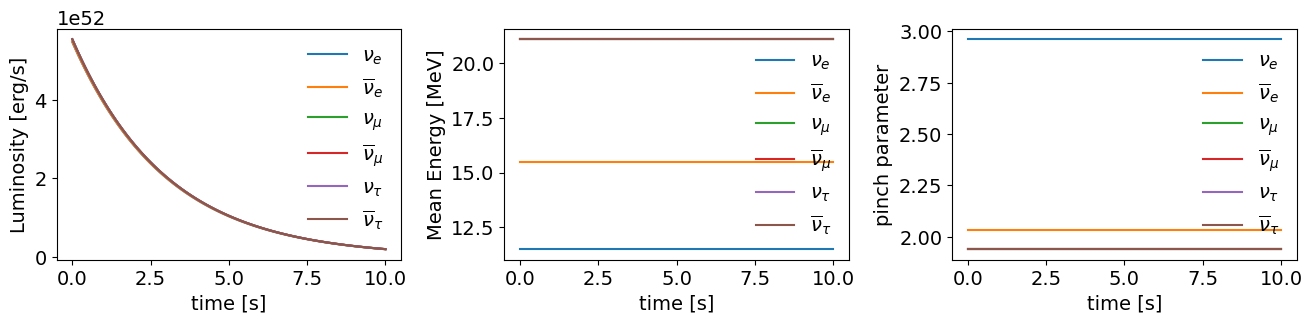

In [3]:
%matplotlib inline
model = Analytic3Species(filename)

fig,axes = plt.subplots(1,3,figsize=(16,3))
plt.subplots_adjust(wspace=0.3)
for flavor in ThreeFlavor:
    axes[0].plot(model.time,model.luminosity[flavor],label=flavor.to_tex())
    axes[1].plot(model.time,model.meanE[flavor],label=flavor.to_tex())
    axes[2].plot(model.time,model.pinch[flavor],label=flavor.to_tex())

axes[0].set_ylabel("Luminosity [erg/s]")
axes[0].set_xlabel("time [s]")
axes[0].legend(frameon=False)

axes[1].set_ylabel("Mean Energy [MeV]")
axes[1].set_xlabel("time [s]")
axes[1].legend(frameon=False)

axes[2].set_ylabel("pinch parameter")
axes[2].set_xlabel("time [s]")
axes[2].legend(frameon=False)
plt.show()


## Calculating Number of Events

In [4]:
# set up the model for the neutrino emission from the supernova
model = Analytic3Species(filename)

# set the desired Oscillation scenario
transformation = NoTransformation()

# set distance in kpc
distance=10 * u.kpc

# first we create the flux as a function of time and energy
energies = np.linspace(0,100,501) * u.MeV
flux = model.get_flux(t=times, E=energies, distance=distance, flavor_xform=transformation)

# then integrate the flux over the entire range of time for the model to make the rate calculation more efficient
fluence = flux.integrate('time')

# set the desired detector - this is the SNOwGLoBES detector name 
detector='wc100kt30prct'

# set up the RateCalculator
rc = RateCalculator()

# Run the fluence through the RateCalculator - which does the same calculation as SNOwGLoBES 
# We will include the detector effects of smearing and efficiency 
# Note that when the detector_effects are include, the events returned by the RateCalculator have been integrated over each energy bin
# The collate function combines all the neutral current and electron elastic scattering channels in the tables returned by the RateCalculator 

events = collate( rc.run(fluence, detector, detector_effects=True) )

# Compute number of events in all interaction channels of the detector including smearing
total_events  = sum([chan.integrate_or_sum('energy').array.squeeze().value for chan in events.values()])

print("Total events in Super-K-like detector (with smearing):" , 0.32*total_events)

Total events in Super-K-like detector (with smearing): 26689.245513969094


/home/jpknelle/.local/lib/python3.12/site-packages/snewpy/rate_calculator.py:357: RuntimeWarning: divide by zero encountered in log
  return np.interp(np.log(E)/np.log(10), xp, yp, left=0, right=0)*E*1e-38 <<u.cm**2


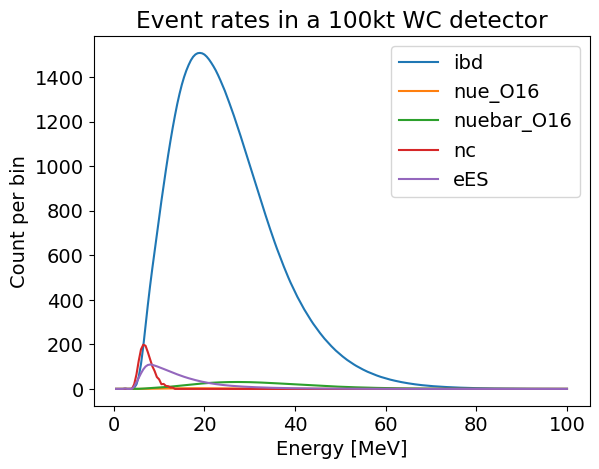

In [5]:
# plot the event numbers in the energy bins 
# use the center function from the rate_calculator module to get the energy bin centers
for channel in events:
    plt.plot(center(events[channel].energy.to('MeV')),events[channel].array.squeeze() ,label=channel)
         
plt.legend()
plt.title('Event rates in a 100kt WC detector')
plt.xlabel("Energy [MeV]")
plt.ylabel("Count per bin")
plt.show()